## 1) Estimator 이해 및 fit(), predict() 메서드
1. ML 모델 학습엔 fit(), 학습된 모델 예측엔 predict() 메서드를 일괄적으로 사용
2. Estimator 클래스 : 지도학습의 모든 알고리즘을 구현한 클래스
1) 분류 알고리즘은 Classifier, 회귀 알고리즘은 Regressor로 지칭. 이 둘은 Estimator로 통칭
2) evaluation 함수, 하이퍼파라미터 튜닝 지원 클래스 등은 Estimator를 인자로 받음
3. 비지도학습(예 : 차원축소, 클러스터링, 피처 추출) 클래스 역시 fit(), transform() 지원
1) fit() : 입력 데이터의 형태에 맞춰 데이터 변환하기 위한 사전 구조를 맞추는 작업
2) transform() : 사전 구조 맞춘 뒤, 입력 데이터의 차원 변환, 클러스터링, 피처 추출 등 실제 작업을 수행
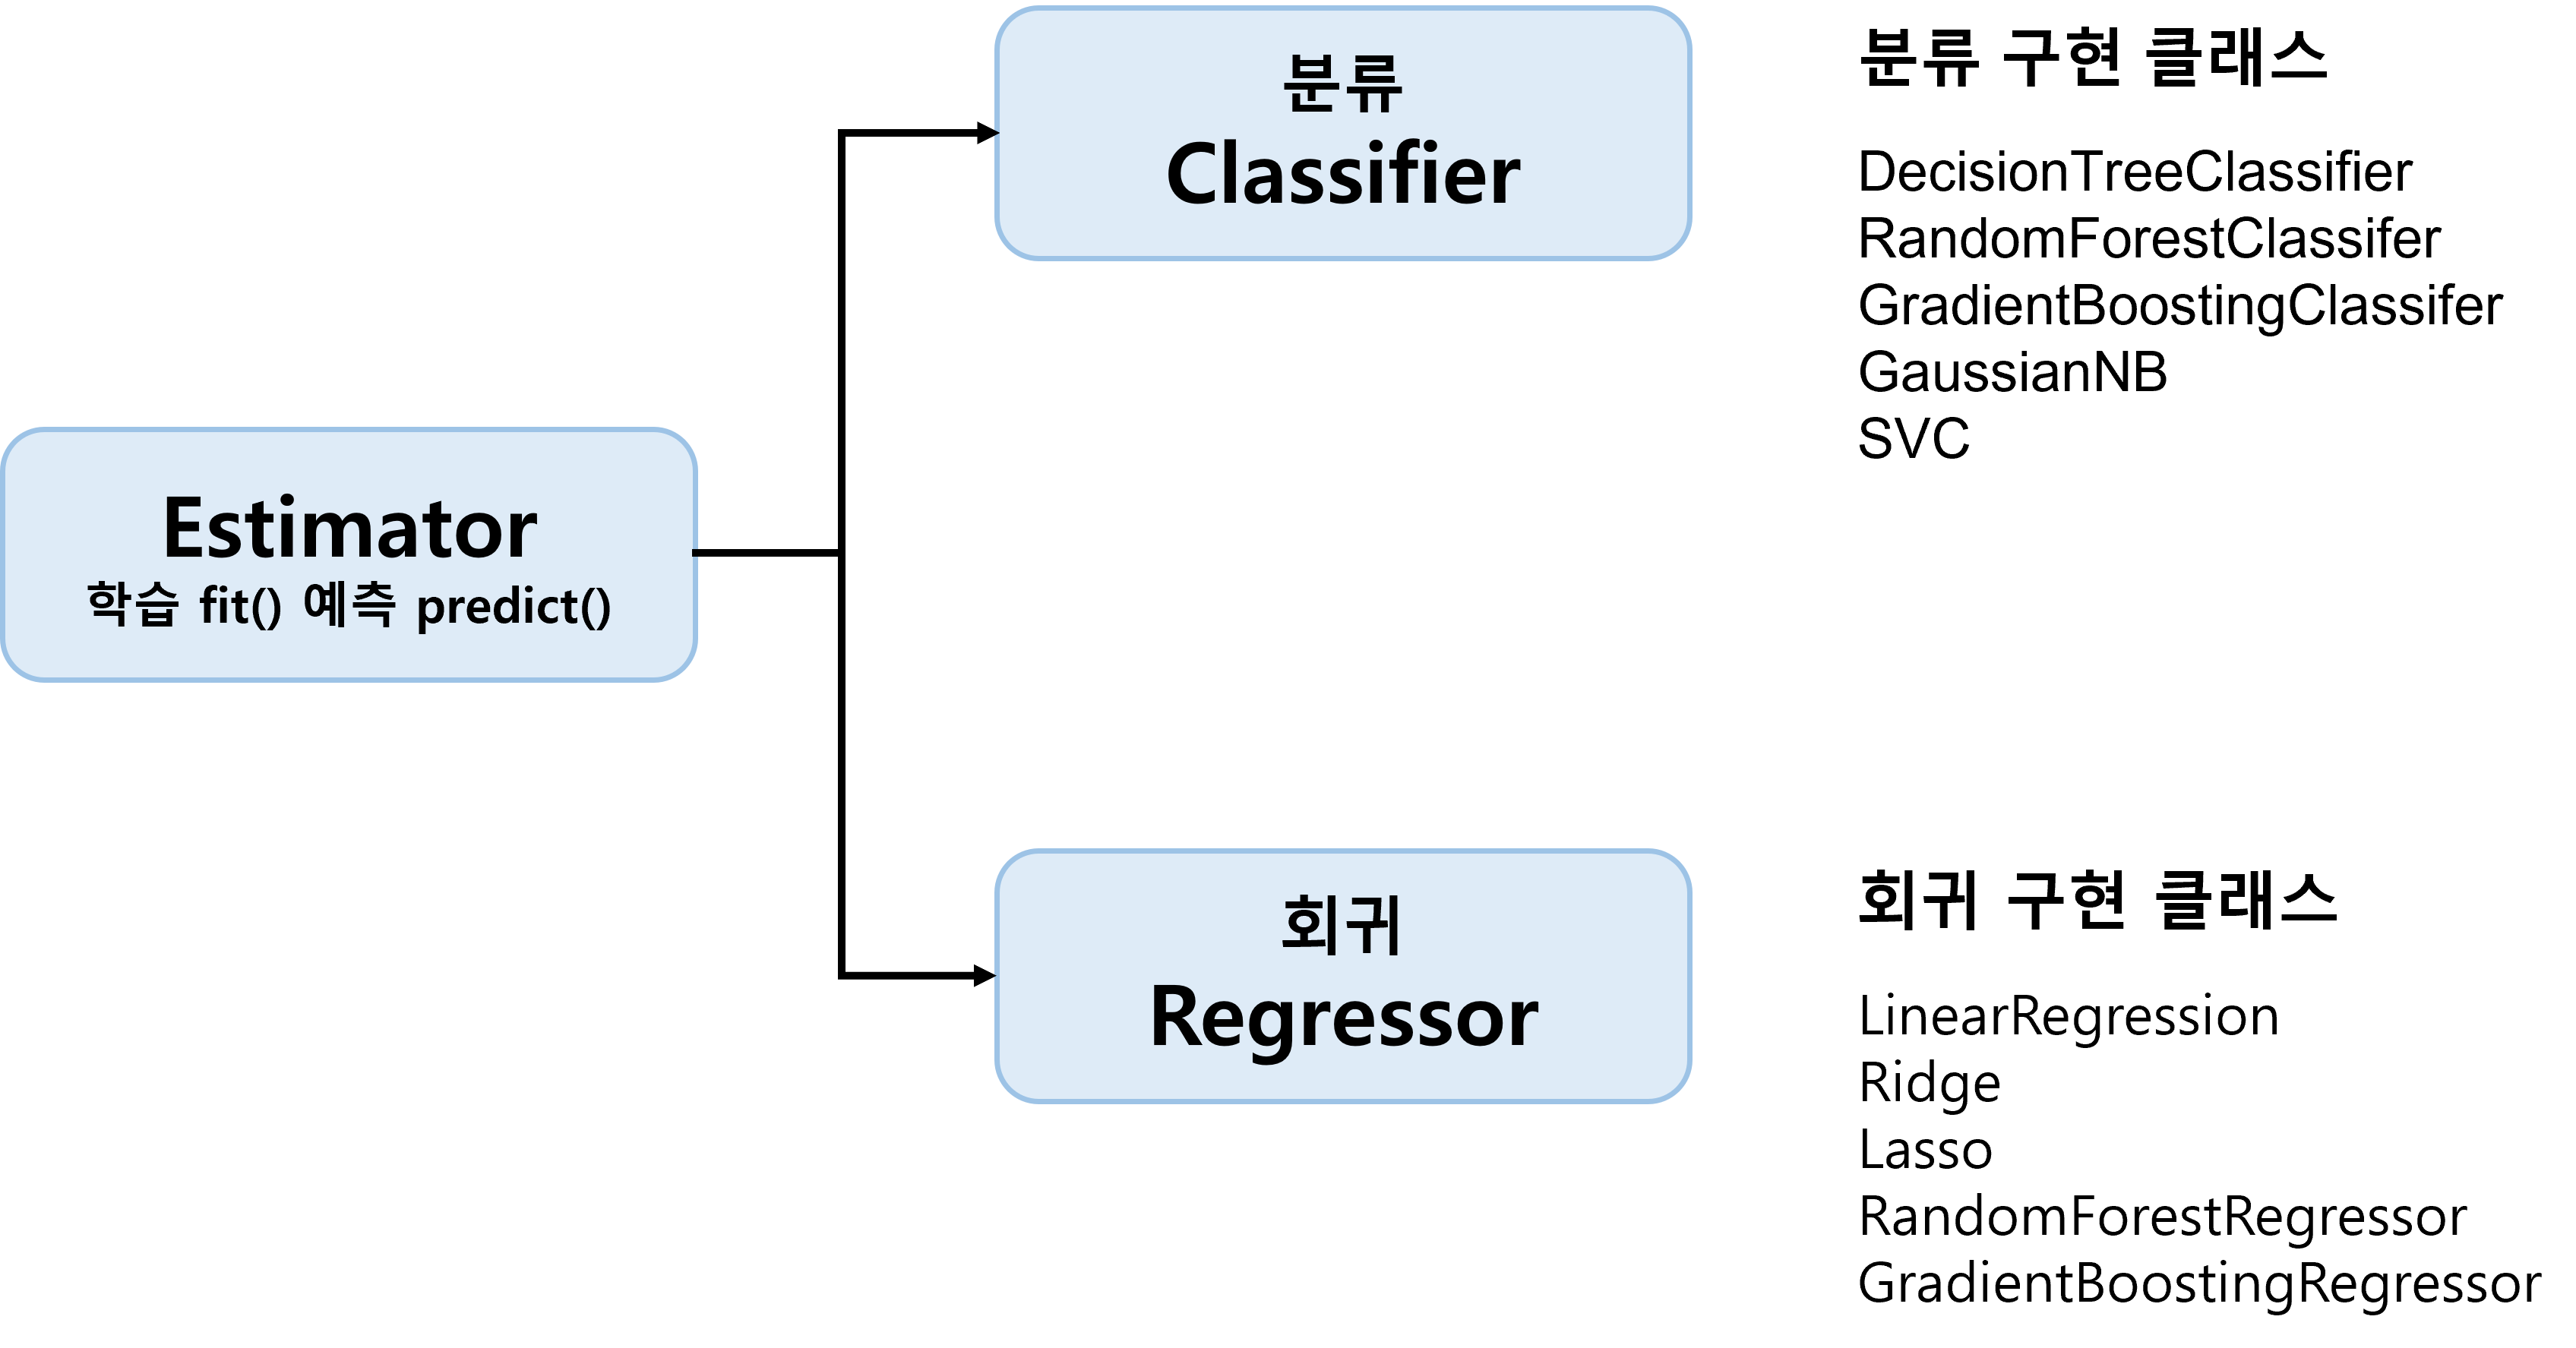

## 2) 사이킷런의 주요 모듈
1. 

## 3) 내장된 예제 데이터 세트
1. 분류/회귀 연습용 예제 데이터 API
1) 회귀 : datasets.load_boston(), datasets.load_diabetes()
2) 분류 : datasets.load_breast_cancer(), datasets.load_digits(), datasets.load_iris()
2. fetch 계열의 명령
1) 데이터 크기 커서 패키지에 처음부터 저장되어 있지 않음
2) 인터넷에서 내려받아 홈 디렉터리 아래 scikit_learn_data라는 서브 디렉터리에 저장한 뒤 추후 불러들이는 데이터
3) 예 : fetch_covtype(), fetch_20newsgroups(), fetch_mldata() 등
3. 분류/클러스터링 위한 표본 데이터 생성기
1) datasets.make_classifications() : 분류를 위한 데이터셋을 만듦. 높은 상관도&불필요 속성 등 노이즈 효과를 위한 데이터를 무작위로 생성
2) datasets.make_blobs() : 클러스터링을 위한 데이터셋을 무작위로 생성. 군집 지정 개수 따라 여러 클러스터링 위한 데이터셋을 쉽게 만듦
4. 사이킷런 내장 데이터셋은 딕셔너리 형태로 되어 있음
1) key : data(피처의 데이터셋), target(분류 시 데이터값. 회귀 시 숫자 결과값 데이터셋), target_name(개별 레이블 이름), feature_names(피처 이름), DESCR(데이터셋 설명, 각 피처 설명)
2) 피처 데이터값 변환받으려면 내장 데이터셋 API 호출 뒤 그 key 값을 지정함

In [2]:
from sklearn.datasets import load_iris

iris_data = load_iris() #붓꽃 데이터셋 생성
print(type(iris_data)) #<class 'sklearn.utils.Bunch'>로, Bunch는 딕셔너리 자료형과 유사

<class 'sklearn.utils.Bunch'>


In [3]:
keys = iris_data.keys() #데이터 키는 피처들의 데이터값임
print('붓꽃 데이터셋의 키 : ', keys)
# 데이터셋이 딕셔너리라 피처 데이터값 추출하려면 dataset.key 또는 dataset['key']로

붓꽃 데이터셋의 키 :  dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename'])


In [4]:
print('feature_names의 type : ', type(iris_data.feature_names))
print('feature_names의 shpae : ', len(iris_data.feature_names))
print(iris_data.feature_names)

print('\n target_names의 type : ', type(iris_data.target_names))
print('target_names의 shape : ', len(iris_data.target_names))
print(iris_data['data'])

print('\n target의 type : ', type(iris_data.target))
print('target의 shape : ', len(iris_data.target))
print(iris_data.target)

feature_names의 type :  <class 'list'>
feature_names의 shpae :  4
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

 target_names의 type :  <class 'numpy.ndarray'>
target_names의 shape :  3
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 